In [1]:
# 1st: clean_spark
# 2nd: if doesn't work, clean_spark + restart kernel
# 3rd: if doesn't work, podman-compose down

In [2]:
# censys_pdf = censys_df.pandas_api()  # OK, SUBSET OF PANDAS API
# censys_df.toPandas()  # BE CAREFUL, THIS MAY CRASH YOUR ENVIRONMENT (needs podman-compose down)

In [1]:
# this creates your spark instance; if you clean_spark, you need to run this again
# you likely don't need to change the configurations inside this file
%run ../spark-instance.ipynb

SparkConf created
Started SparkSession
Spark version 4.0.2
You should be able to access the Spark UI at: https://dacs-compute-gate.ewi.utwente.nl:9999/user/g.luvizottocesar@utwente.nl/proxy/4040/stages/
Note that you may have to Enable extensions first via the Extension Manager.


In [ ]:
# RUN THIS BEFORE RESTARTING THE PYTHON KERNEL
# RUN THIS IF YOU WANT TO RESTART YOUR SPARK INSTANCE
# run podman-compose down if you mess up this and you need to restart your jupyter
clean_spark()

In [5]:
# INSTALL ANY PYTHON PACKAGE YOU NEED HERE!!
# restart the kernel after installing new pkgs
#!pip install <pkg_name>

In [3]:
# system imports
import os
from datetime import datetime

# installed pkg imports
import numpy as np
import pandas as pd
import ipaddress

# spark imports
import pyspark.sql.functions as psf
import pyspark.sql.types as pst
from pyspark.storagelevel import StorageLevel
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, LongType, BooleanType, ArrayType, DoubleType



# download anycast census
import requests # query github
import gzip # read .json.gz files


# plotting
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.patheffects as path_effects

# configure matplotlib variables (font and size)
plt.rcParams["axes.labelsize"] = 20
plt.rcParams.update({'font.size': 14})


In [4]:
# About Censys data: https://search.censys.io/
# https://search.censys.io/search/definitions?resource=hosts

ts = datetime(2026, 2, 3)
CENSYS_BASE_PATH_FMT = "s3a://censys/dataset=universal-internet-dataset-v2-ipv4/format=parquet/"
CENSYS_PATH_FMT = os.path.join(CENSYS_BASE_PATH_FMT, "year={year}/month={month:02d}/day={day:02d}")

In [12]:
censys_path = CENSYS_PATH_FMT.format(year=ts.year, month=ts.month, day=ts.day)
censys_df = spark.read.option("basePath", CENSYS_BASE_PATH_FMT).parquet(censys_path)

In [6]:
def download_date(year, month, day, version) -> pd.DataFrame:
    """Download and return census data for a specific date as a DataFrame.

    Args:
        year (int): The year of the data to download.
        month (int): The month of the data to download.
        day (int): The day of the data to download.
        version (str): The version of the census data ('v4' or 'v6').

    Returns:
        pd.DataFrame: DataFrame containing the census data for the specified date.
    """
    # Return error if date is before census start (2024/03/20)
    if (year, month, day) < (2024, 3, 20):
        raise ValueError("Date is before census start date of 2024-03-20")

    # Return error if date is in the future
    if datetime(year, month, day) > datetime.now():
        raise ValueError("Date is in the future")

    # URL e.g., https://github.com/ut-dacs/anycast-census/blob/main/2025/10/31/IPv4.parquet
    date_str = f"{year:04d}/{month:02d}/{day:02d}"
    url = f"https://github.com/ut-dacs/anycast-census/blob/main/{date_str}/IP{version}.parquet?raw=true"

    response = requests.get(url)
    if response.status_code != 200:
        raise Exception(f"Failed to download {url}: HTTP {response.status_code}")

    # Get the URL content as a bytes object
    data_bytes = response.content
    # Read the Parquet data into a DataFrame
    df = pd.read_parquet(pd.io.common.BytesIO(data_bytes))
    return df

In [11]:
# censys schema TODO assess interesting fields from this
censys_df.printSchema()

In [9]:
# define LACeS struct

# locations of anycast sites
location_struct = StructType([
    StructField("city", StringType(), True),
    StructField("code_country", StringType(), True), 
    StructField("id", StringType(), True),
    StructField("latitude", DoubleType(), True), 
    StructField("longitude", DoubleType(), True)
])

# schema
full_schema = StructType([
    StructField("prefix", StringType(), True),
    StructField("AB_ICMPv4", LongType(), True),
    StructField("AB_TCPv4", LongType(), True),
    StructField("AB_DNSv4", LongType(), True),
    StructField("GCD_ICMPv4", LongType(), True),
    StructField("GCD_TCPv4", LongType(), True),
    StructField("partial", BooleanType(), True),
    StructField("backing_prefix", StringType(), True),
    StructField("ASN", StringType(), True),
    # list of location structs
    StructField("locations", ArrayType(location_struct), True) 
])


In [10]:
# load in anycast data

anycast_df = download_date(ts.year, ts.month, ts.day, "v4")
anycast_df = anycast_df[anycast_df['GCD_ICMPv4'] > 1] # filter on GCD-confirmed (high accuracy)

anycast_df.head()

,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations
0,1.0.0.0/24,29,29,27,75,12,False,1.0.0.0/24,13335,"[{'city': 'Bangalore', 'country_code': 'IN', '..."
1,1.1.1.0/24,29,29,27,74,14,False,1.1.1.0/24,13335,"[{'city': 'Bangalore', 'country_code': 'IN', '..."
3,1.10.10.0/24,3,0,2,3,0,False,1.10.10.0/24,148000,"[{'city': 'Mumbai', 'country_code': 'IN', 'id'..."
4,1.12.0.0/24,5,0,4,5,0,False,1.12.0.0/20,132203_45090,"[{'city': 'Baltimore', 'country_code': 'US', '..."
5,1.12.12.0/24,3,1,0,3,1,False,1.12.0.0/20,132203_45090,"[{'city': 'Hong Kong', 'country_code': 'HK', '..."


In [13]:
anycast_spark_df = spark.createDataFrame(anycast_df, schema=full_schema)

anycast_spark_df.printSchema()
anycast_spark_df.show(1, truncate=False)

root
 |-- prefix: string (nullable = true)
 |-- AB_ICMPv4: long (nullable = true)
 |-- AB_TCPv4: long (nullable = true)
 |-- AB_DNSv4: long (nullable = true)
 |-- GCD_ICMPv4: long (nullable = true)
 |-- GCD_TCPv4: long (nullable = true)
 |-- partial: boolean (nullable = true)
 |-- backing_prefix: string (nullable = true)
 |-- ASN: string (nullable = true)
 |-- locations: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- city: string (nullable = true)
 |    |    |-- code_country: string (nullable = true)
 |    |    |-- id: string (nullable = true)
 |    |    |-- latitude: double (nullable = true)
 |    |    |-- longitude: double (nullable = true)

+----------+---------+--------+--------+----------+---------+-------+--------------+-----+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [10]:
# get unique anycast prefixes
anycast_prefixes = anycast_spark_df.select("prefix").distinct().collect()

# Show first 5 prefixes
print([row["prefix"] for row in anycast_prefixes[:5]])


['134.231.245.0/24', '137.66.32.0/24', '140.248.188.0/24', '141.226.109.0/24', '130.211.11.0/24']


In [11]:
# add /24 prefix column to censys data

censys_df = censys_df.withColumn(
    "prefix",
    psf.concat(
        psf.substring_index("host_identifier.ipv4", ".", 3), 
        psf.lit(".0/24")
    )
)

In [12]:
censys_selectives_df = censys_df.select(
    "prefix",
    "host_identifier",
    "services.port",
    "services.transport",
    "services.service_name",
    # "services.http.response.headers", -> originally used to infer number of unique websites (we use OI data for this)
    "autonomous_system", # contains more than just ASN
    #"locations", # spams output (put at end) -> temporarily disabled, explodes dataframe significantly (cause of slowness?)
)


anycast_selectives_df = anycast_spark_df.select(
    "prefix", 
    "GCD_ICMPv4", 
    "partial", 
    #"backing_prefix", 
    #"ASN"
)


# join censys and anycast datasets

# TODO handle MOASes (Verisign will show up with a lot of anycast ASes but in reality it's only a single AS)

censys_anycast_df = censys_selectives_df.join(
    F.broadcast(anycast_selectives_df),
    on="prefix",
    how="inner"
).select( # TODO add all required columns here
    "prefix",
    "GCD_ICMPv4",
    "partial",
    #"ASN", -> in 'autonomous_system'
    #"backing_prefix", -> in 'autonomous_system'
    "host_identifier",
    "port",
    "transport",
    "service_name",
    # "services.http.response.headers", -> originally used to infer number of unique websites (we use OI data for this)
    "autonomous_system", # contains more than just ASN
    #"locations", # spams output (put at end) -> temporarily disabled, explodes dataframe significantly (cause of slowness?)
)

In [ ]:
# CAREFUL, RUN ONCE!
censys_anycast_df.write.parquet(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/censys/dataset=universal-internet-dataset-v2-ipv4/year={ts.year}/month={ts.month:02d}/day={ts.day:02d}")

In [14]:
censys_anycast_df = spark.read.parquet(f"s3a://luvizottocesarg-tmp/anycast-service-discovery/censys/dataset=universal-internet-dataset-v2-ipv4/year={ts.year}/month={ts.month:02d}/day={ts.day:02d}")

In [15]:
# persist
censys_anycast_df.persist(StorageLevel.MEMORY_AND_DISK)
censys_anycast_df.count() # trigger persistance

1173113

In [19]:
# show first row
censys_anycast_df.show(1, truncate=False)

+---------------+----------+-------+--------------------------+-----------------------------+-------------------------+---------------------------------+-----------------------------------------------------------------+
|prefix         |GCD_ICMPv4|partial|host_identifier           |port                         |transport                |service_name                     |autonomous_system                                                |
+---------------+----------+-------+--------------------------+-----------------------------+-------------------------+---------------------------------+-----------------------------------------------------------------+
|43.159.102.0/24|14        |false  |{43.159.102.5, NULL, NULL}|[80, 443, 8080, 65530, 65531]|[TCP, TCP, TCP, TCP, TCP]|[HTTP, HTTP, HTTP, HTTP, UNKNOWN]|{139341, ACE-AS-AP ACE, 43.159.102.0/24, ACE-AS-AP ACE, SG, NULL}|
+---------------+----------+-------+--------------------------+-----------------------------+-------------------------+-

In [20]:
censys_anycast_df.printSchema()

root
 |-- prefix: string (nullable = true)
 |-- GCD_ICMPv4: long (nullable = true)
 |-- partial: boolean (nullable = true)
 |-- host_identifier: struct (nullable = true)
 |    |-- ipv4: string (nullable = true)
 |    |-- ipv6: string (nullable = true)
 |    |-- name: string (nullable = true)
 |-- port: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- transport: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- service_name: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- autonomous_system: struct (nullable = true)
 |    |-- asn: long (nullable = true)
 |    |-- description: string (nullable = true)
 |    |-- bgp_prefix: string (nullable = true)
 |    |-- name: string (nullable = true)
 |    |-- country_code: string (nullable = true)
 |    |-- organization: string (nullable = true)



# General Data

In [17]:
total_anycast_ips = censys_anycast_df.select('host_identifier.ipv4').distinct().count()
total_anycast_prefixes = censys_anycast_df.select('prefix').distinct().count()
total_anycast_asns = censys_anycast_df.select('autonomous_system.asn').distinct().count()

# print(f"Original Censys IPs: {censys_df.select('host_identifier.ipv4').distinct().count():,}") 249,609,996
print(f"Total Censys IPs in Anycast subnets: {total_anycast_ips:,}")
# old 2024: Total Censys IPs in Anycast subnets: 2,180,518

Total Censys IPs in Anycast subnets: 1,173,113


In [18]:
unmatched_prefixes = anycast_selectives_df.select("prefix").distinct().join(
    censys_selectives_df.select("prefix").distinct(),
    on="prefix",
    how="left_anti"
)
total = anycast_selectives_df.select("prefix").distinct().count() # Total number of Anycast /24 prefixes
unmatched = unmatched_prefixes.count() # Anycast /24 prefixes that weren't found in the Censys data
matched = total - unmatched
print(f"Total anycast /24 prefixes: {total:,}")
print(f"Total unmatched prefixes: {unmatched:,}")
print(f"Total matched prefixes: {matched:,}")

print(f"Matched prefixes: {(100 * (total - unmatched) / total):.2f}%")
#print(f"Average IPs per /24 prefix: {(total_censys_anycast/matched):.2f}")
# from 2024
#Total anycast /24 prefixes: 12,180
#Total unmatched prefixes: 460
#Total matched prefixes: 11,720
#Matched prefixes: 96.22%

Total anycast /24 prefixes: 14,332
Total unmatched prefixes: 1,122
Total matched prefixes: 13,210
Matched prefixes: 92.17%


In [19]:
# get total number of services (exploded transport lists)
exploded_df = censys_anycast_df \
    .select(
        "host_identifier",
        "autonomous_system.asn",
        "prefix", 
        F.explode_outer("transport").alias("protocol")
    ) \
    .filter(F.col("protocol").isNotNull())

total_services_global = exploded_df.count() # total number of services found


# combine all metrics into one
# 1) total services for each transport layer protocol
# 2) total anycast IPs for each transport layer protocol (TODO should we exclude partial prefixes for this?)
# 3) total anycast prefixes for each transport layer protocol
protocol_stats = exploded_df \
    .groupBy("protocol") \
    .agg(
        # total services (e.g., IP has 3 TCP ports -> Count 3)
        F.count("*").alias("total_services"),
        
        # services by unique IPs (e.g., IP has 3 TCP ports -> Count 1) (e.g., how many IPs have a TCP service running?)
        F.countDistinct("host_identifier").alias("ip_count"),
        
        # services by unique prefixes (e.g., how many prefixes have a UDP service running
        F.countDistinct("prefix").alias("prefix_count"),

        # count by ASNs
        F.countDistinct("asn").alias("asn_count") 
    ) \
    .withColumn("services_pct", F.round((F.col("total_services") / total_services_global) * 100, 2)) \
    .withColumn("ip_pct", F.round((F.col("ip_count") / total_anycast_ips) * 100, 2)) \
    .withColumn("prefix_pct", F.round((F.col("prefix_count") / total_anycast_prefixes) * 100, 2)) \
    .withColumn("asn_pct", F.round((F.col("asn_count") / total_anycast_asns) * 100, 2)) \
    .select(
        "protocol", 
        "total_services", "services_pct", 
        "ip_count", "ip_pct", 
        "prefix_count", "prefix_pct",
        "asn_count", "asn_pct",
    ) \
    .orderBy(F.col("total_services").desc())

protocol_stats.show(truncate=False)

+--------+--------------+------------+--------+------+------------+----------+---------+-------+
|protocol|total_services|services_pct|ip_count|ip_pct|prefix_count|prefix_pct|asn_count|asn_pct|
+--------+--------------+------------+--------+------+------------+----------+---------+-------+
|TCP     |8472218       |98.41       |1131204 |96.43 |11977       |90.67     |621      |76.48  |
|UDP     |84201         |0.98        |65326   |5.57  |4635        |35.09     |574      |70.69  |
|QUIC    |52382         |0.61        |52382   |4.47  |3839        |29.06     |14       |1.72   |
+--------+--------------+------------+--------+------+------------+----------+---------+-------+



In [21]:
# convert to latex table

# convert to pandas first
pdf = protocol_stats.toPandas()

# format with thousand separator and percentage in paranthesis (e.g., `1,100,213 (81.23\%)`)
def format_metric(count, pct):
    return f"{int(count):,} ({pct:.0f}\\%)"

# combine counts and percentages
pdf['Total Services Combined'] = pdf.apply(
    lambda x: format_metric(x['total_services'], x['services_pct']), axis=1
)

pdf['IP Count Combined'] = pdf.apply(
    lambda x: format_metric(x['ip_count'], x['ip_pct']), axis=1
)

pdf['Prefix Count Combined'] = pdf.apply(
    lambda x: format_metric(x['prefix_count'], x['prefix_pct']), axis=1
)

pdf['ASN Count Combined'] = pdf.apply(
    lambda x: format_metric(x['asn_count'], x['asn_pct']), axis=1
)

# rename columns
final_table = pdf[[
    'protocol', 
    'Total Services Combined', 
    'IP Count Combined', 
    'Prefix Count Combined',
    'ASN Count Combined',
]]

final_table.columns = [
    "Protocol", 
    "Total Services", 
    "Active IPs", 
    "/24s",
    "ASes",
]

# generate latex
latex_output = final_table.to_latex(
    index=False,
    escape=False, 
    caption="Transport Layer Protocols Statistics",
    label="tab:transport_protocols"
)

print(latex_output)

\begin{table}
\caption{Transport Layer Protocols Statistics}
\label{tab:transport_protocols}
\begin{tabular}{lllll}
\toprule
Protocol & Total Services & Active IPs & /24s & ASes \\
\midrule
TCP & 8,472,218 (98\%) & 1,131,204 (96\%) & 11,977 (91\%) & 621 (76\%) \\
UDP & 84,201 (1\%) & 65,326 (6\%) & 4,635 (35\%) & 574 (71\%) \\
QUIC & 52,382 (1\%) & 52,382 (4\%) & 3,839 (29\%) & 14 (2\%) \\
\bottomrule
\end{tabular}
\end{table}



# Analyzing the services running on Anycast

Comparing with our own measurements

In [23]:
censys_anycast_df.printSchema()

root
 |-- prefix: string (nullable = true)
 |-- GCD_ICMPv4: long (nullable = true)
 |-- partial: boolean (nullable = true)
 |-- host_identifier: struct (nullable = true)
 |    |-- ipv4: string (nullable = true)
 |    |-- ipv6: string (nullable = true)
 |    |-- name: string (nullable = true)
 |-- port: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- transport: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- service_name: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- autonomous_system: struct (nullable = true)
 |    |-- asn: long (nullable = true)
 |    |-- description: string (nullable = true)
 |    |-- bgp_prefix: string (nullable = true)
 |    |-- name: string (nullable = true)
 |    |-- country_code: string (nullable = true)
 |    |-- organization: string (nullable = true)



In [16]:
ports_pdf = pd.read_csv("lzr_ports.txt", header=None)
ports_pdf.columns = ["port"]
ports = ports_pdf["port"].to_list()
#ports_df = spark.createDataFrame(ports_pdf)
#ports_df.count()

In [17]:
services_pdf = pd.read_csv("all_fingerprints.csv")
services_pdf["fingerprint"] = services_pdf["fingerprint"].replace({
    "memcached_ascii": "memcached",
    "memcached_binary": "memcached",
    "pop3-redis": "pop3",
    "quic-doq": "quic",
    "quic-h3": "quic",
    "smtp-ftp": "smtp"
}).str.upper()

services_pdf = services_pdf.drop_duplicates().reset_index(drop=True)

services = services_pdf["fingerprint"].to_list()

In [22]:
censys_anycast_df.select(
    "prefix",
    F.explode_outer(F.arrays_zip("port", "transport")).alias("pair")
).select(
    "prefix",
    F.col("pair.port").alias("p"),
    F.col("pair.transport").alias("transport"),
).filter(
    F.col("p").isin(ports)
).filter(
    F.col("transport") == "QUIC"
).select("prefix").distinct().count()

3839

In [23]:
censys_anycast_df.select(
    "prefix",
    F.explode_outer(F.arrays_zip("port", "transport")).alias("pair")
).select(
    "prefix",
    F.col("pair.port").alias("p"),
    F.col("pair.transport").alias("transport"),
).filter(
    F.col("transport") == "QUIC"
).select("prefix").distinct().count()

3839

In [29]:
censys_anycast_df.select(psf.explode_outer("service_name").alias("fingerprint")).distinct().toPandas(
).to_csv("censys_all_fingerprints.csv", index=False)

In [18]:
meas_agg_pdf = censys_anycast_df.select(
    "prefix",
    F.explode_outer(F.arrays_zip("port", "service_name")).alias("pair")
).select(
    "prefix",
    F.col("pair.port").alias("p"),
    F.col("pair.service_name").alias("fingerprint")
).filter(
    (
        F.col("p").isin(ports)
        & F.col("fingerprint").isin(services)
        #& F.col("fingerprint") != "UNKNOWN"
    )
).groupBy("fingerprint").agg(
    F.countDistinct("prefix").alias("count")
).toPandas()

In [58]:
meas_agg_pdf.to_csv("censys_fp_prefix_cnt.csv", index=False)

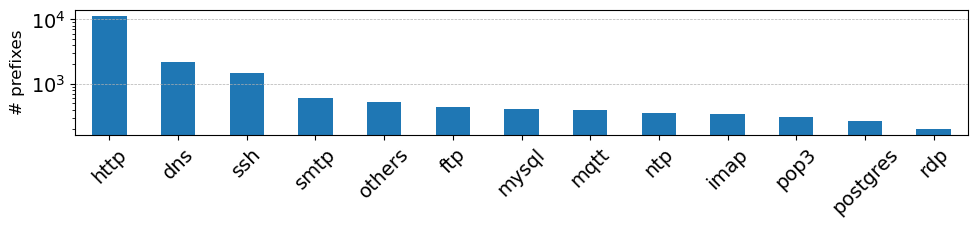

In [56]:
def plot_services_prefix(meas_agg_pdf, filename):
    # Convert to a Series indexed by fingerprint
    meas_agg_pdf["fingerprint"] = meas_agg_pdf["fingerprint"].str.lower()
    plot_df = meas_agg_pdf.set_index("fingerprint")["count"]
    
    # Identify services with count < 100
    mask_other = plot_df < 100
    
    # Sum them into a single "others" value
    other_value = plot_df[mask_other].sum()
    
    # Keep only services that are NOT "other"
    plot_df = plot_df[~mask_other]
    
    # Append the aggregated "others"
    plot_df.loc["others"] = other_value
    
    # Sort descending
    plot_df = plot_df.sort_values(ascending=False)
    
    ax = plot_df.plot(
        kind="bar",
        figsize=(10, 2.5),
    )
    
    ax.set_xlabel("")
    ax.set_ylabel("# prefixes", fontsize=12)
    ax.set_title("")
    ax.set_yscale("log")
    ax.yaxis.grid(True, linestyle="--", linewidth=0.5) #, which="both")
    ax.legend().remove()  # single series — no legend needed
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(filename, dpi=600)
    plt.show()

plot_services_prefix(meas_agg_pdf, "figures/censys_services_prefix_tls_others.pdf")

In [54]:
all_meas_agg_pdf = censys_anycast_df.select(
    "prefix",
    F.explode_outer(F.arrays_zip("port", "service_name")).alias("pair")
).select(
    "prefix",
    F.col("pair.port").alias("p"),
    F.col("pair.service_name").alias("fingerprint")
).filter(
    F.col("fingerprint") != "UNKNOWN"
).groupBy("fingerprint").agg(
    F.countDistinct("prefix").alias("count")
).toPandas()

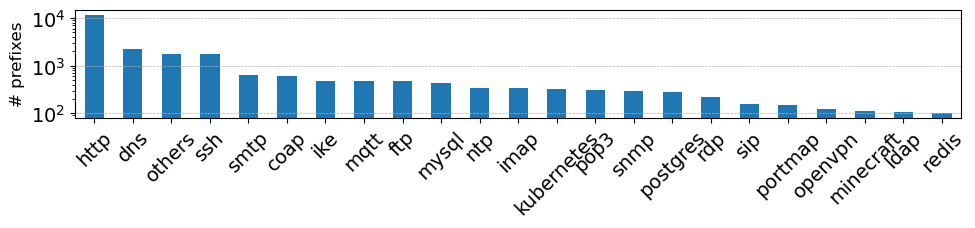

In [57]:
plot_services_prefix(all_meas_agg_pdf, "figures/censys_all_services_prefix_tls_others.pdf")

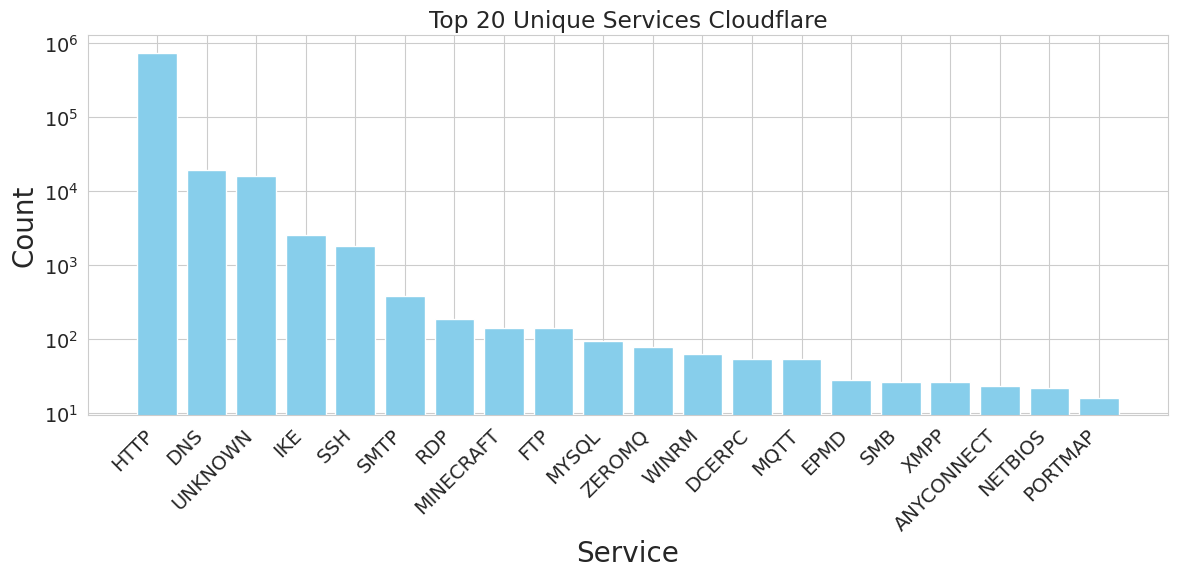

In [98]:
service_cloudflare_pd = service_cloudflare.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_cloudflare_pd["service"], service_cloudflare_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.yscale('log')
plt.title("Top 20 Unique Services Cloudflare")
plt.tight_layout()
plt.show()

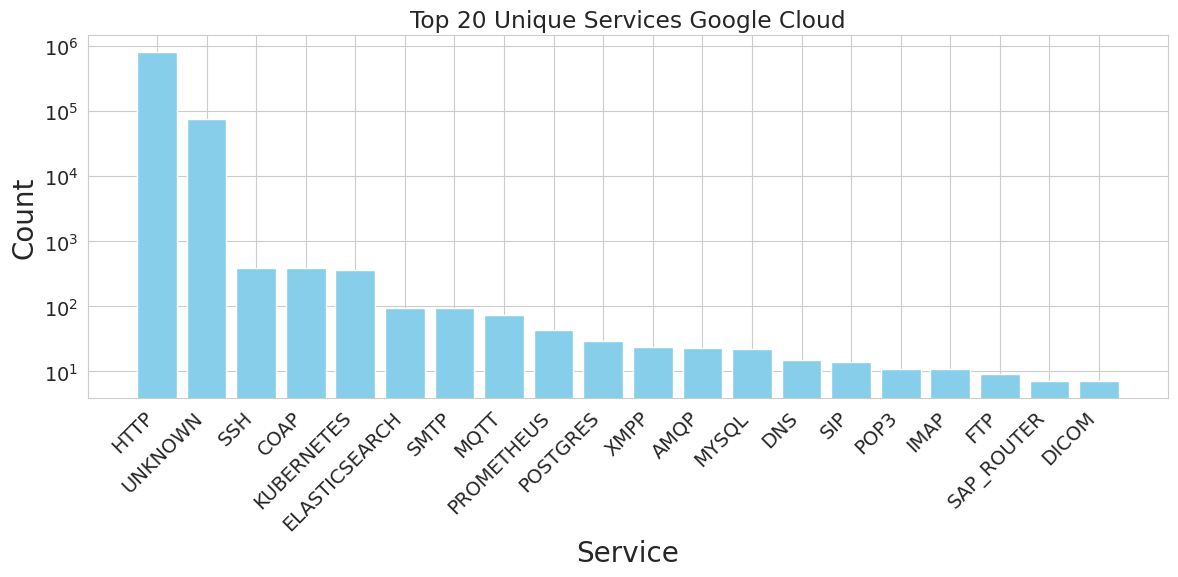

In [99]:
service_google = censys_anycast_df \
    .filter(psf.col("autonomous_system.asn") == 396982) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

service_google_pd = service_google.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_google_pd["service"], service_google_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.yscale('log')
plt.title("Top 20 Unique Services Google Cloud")
plt.tight_layout()
plt.show()

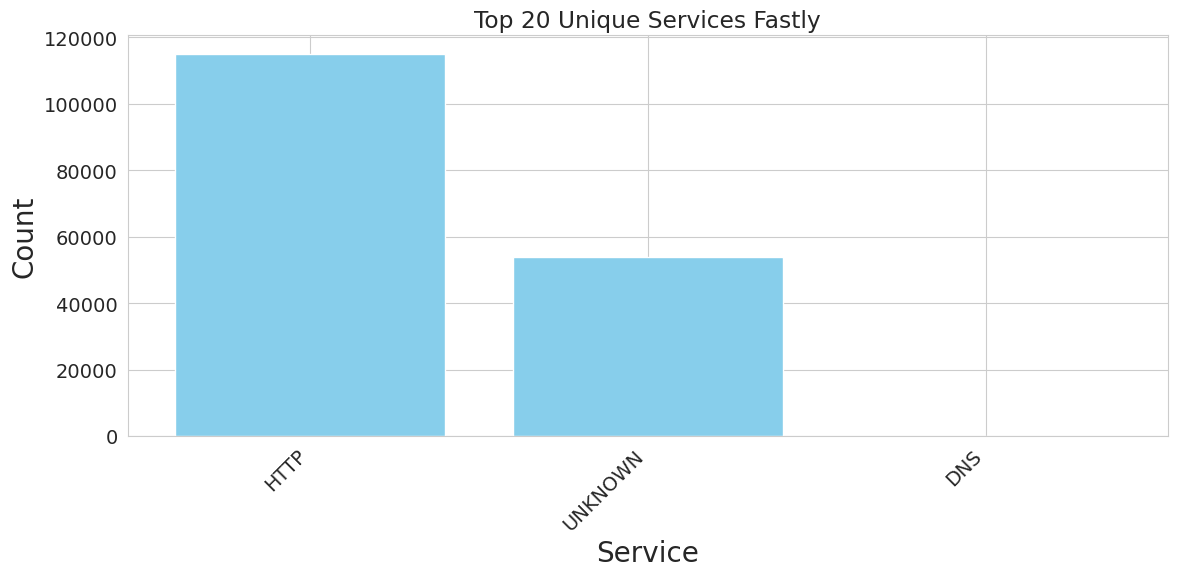

In [102]:
service_fastly = censys_anycast_df \
    .filter(psf.col("autonomous_system.asn") == 54113) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

service_fastly_pd = service_fastly.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_fastly_pd["service"], service_fastly_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 20 Unique Services Fastly")
plt.tight_layout()
plt.show()

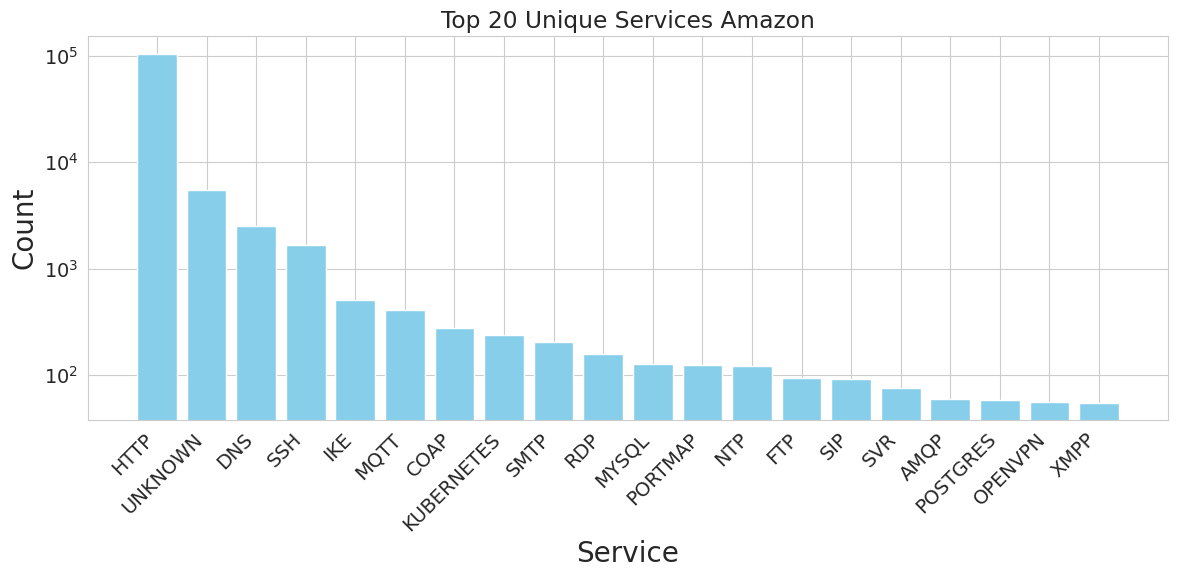

In [103]:
service_amazon = censys_anycast_df \
    .filter(psf.col("autonomous_system.asn") == 16509) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

service_amazon_pd = service_amazon.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_amazon_pd["service"], service_amazon_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.yscale('log')

plt.title("Top 20 Unique Services Amazon")
plt.tight_layout()
plt.show()

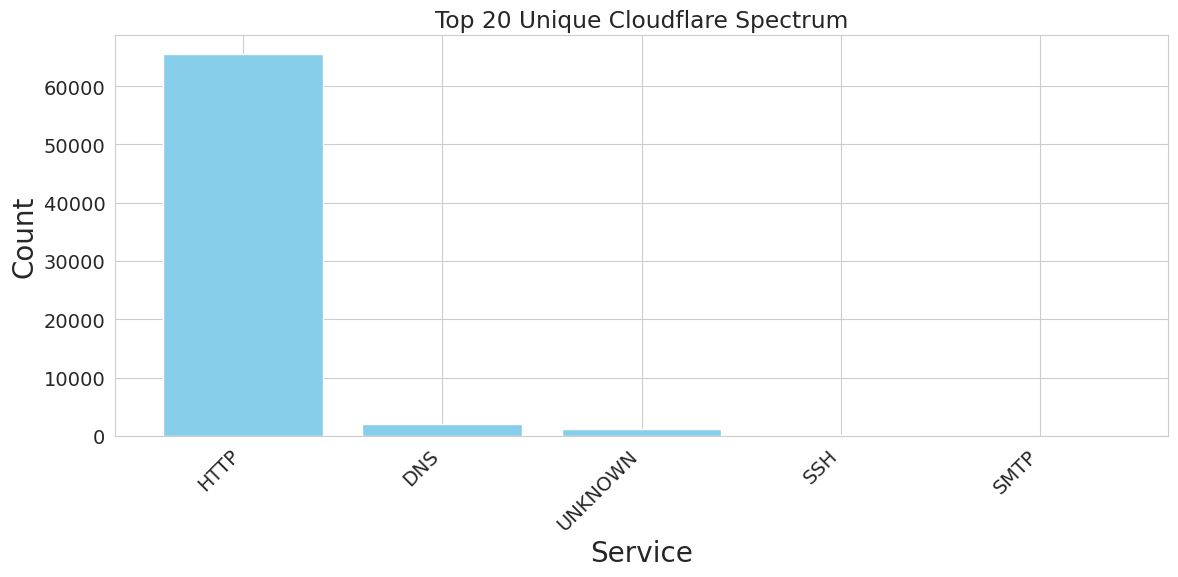

In [104]:
service_cloudflarespec = censys_anycast_df \
    .filter(psf.col("autonomous_system.asn") == 209242) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

service_cloudflarespec_pd = service_cloudflarespec.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_cloudflarespec_pd["service"], service_cloudflarespec_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 20 Unique Cloudflare Spectrum")
plt.tight_layout()
plt.show()

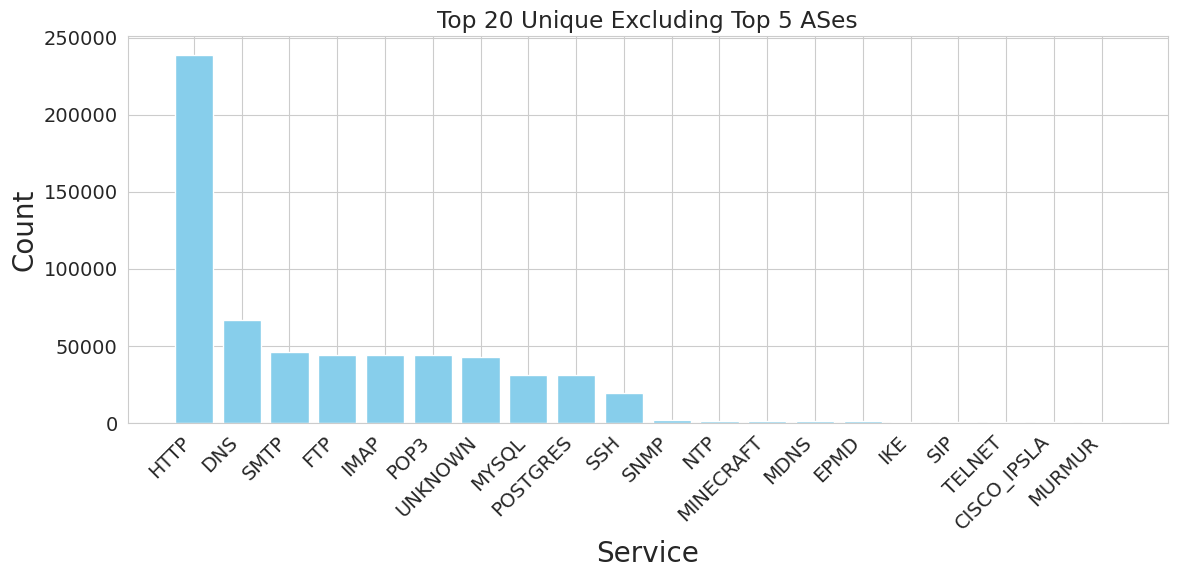

In [105]:
excluded_asns = [396982, 13335, 54113, 16509, 209242]

service_other = censys_anycast_df \
    .filter(~psf.col("autonomous_system.asn").isin(excluded_asns)) \
    .select("host_identifier.ipv4", psf.array_distinct("service_name").alias("unique_services")) \
    .select(psf.explode("unique_services").alias("service")) \
    .groupBy("service") \
    .count() \
    .orderBy("count", ascending=False)

service_other_pd = service_other.limit(20).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(service_other_pd["service"], service_other_pd["count"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Service")
plt.ylabel("Count")
plt.title("Top 20 Unique Excluding Top 5 ASes")
plt.tight_layout()
plt.show()

### Now that the top 5 CDNs are filtered out, the data is a lot more significant. HTTP still dominates over the other services, however we can see how the other services are distributed

In [ ]:
# Define Top 5 ASNs
top5_asns = [396982, 13335, 54113, 16509, 209242]

# Step 1: Label entries as Top 5 vs Other, explode services
exploded_df = (
    censys_anycast_df
    .withColumn("group", psf.when(psf.col("autonomous_system.asn").isin(top5_asns), "Top 5 ASes").otherwise("Other ASes"))
    .withColumn("service", psf.explode("service_name"))
    .filter(psf.col("service") != "UNKNOWN")
    .select("group", "service", "host_identifier.ipv4")
)

# Step 2: Group by service and group, count unique IPs
service_grouped = (
    exploded_df
    .groupBy("service", "group")
    .agg(psf.countDistinct("ipv4").alias("ip_count"))
)

# Step 3: Get top 20 services by total IP count
top_services_df = (
    service_grouped
    .groupBy("service")
    .agg(psf.sum("ip_count").alias("total_ip_count"))
    .orderBy(psf.desc("total_ip_count"))
    .limit(20)
    .select("service")  # Just get the service names
)

# Step 4: Join back to filter original grouped data to top 20 only
top_services = service_grouped.join(top_services_df, on="service", how="inner")

# Step 5: Convert to Pandas for plotting
top_services_pd = top_services.toPandas()

In [ ]:
# Pivot the DataFrame: rows are services, columns are groups ("Top 5 ASes", "Other ASes")
pivot_df = top_services_pd.pivot(index="service", columns="group", values="ip_count").fillna(0)

# Sort by total IP count (Top 5 + Other)
pivot_df["Total"] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values(by="Total", ascending=False).drop(columns="Total")

# Plot
ax = pivot_df.plot(kind="bar", figsize=(14, 6), color=["skyblue", "salmon"])
ax.set_yscale("log")
plt.title("Top 20 Services by Unique IPs: Top 5 ASes vs Other ASes")
plt.ylabel("Unique IP Count (log)")
ax.set_xlabel("")
plt.xticks(rotation=45, ha='right')
plt.legend(title="AS Group")
plt.tight_layout()
plt.savefig("output/tp_service_comparison.pdf", bbox_inches='tight')
plt.show()

SSH is a misconfig  due to laziness. The services deployed for the unicast addresses are also accessible in the anycast addresses. Default kernel behaviour is the speculation.
Look into minecraft anycast
Telnet is old and not secure, top 5 likely already replaced it

In [ ]:
pivot = top_services_pd.pivot(index='service', columns='group', values='ip_count')
print(pivot.head(20))